# Markout vs FIFO Hold Time — Scatter Plots per Ticker

Two scatter plots per ticker (top-10 book):
1. **Signed markout** vs FIFO hold time
2. **|Markout|** vs FIFO hold time

Markout convention (signed): **positive = favorable price move** on the opening
leg (mid moved *with* our position); **negative = adverse selection** (mid moved
*against* the opening fill — the toxic direction that eats capture).

Hold time = time from the opening fill to its FIFO-matched exit (the actual
offset), in seconds.

**A note on scale.** PSX has liquid names (PPL: hundreds of thousands of fills
across the sample) — the raw scatter would just be a solid blob. Each panel
therefore shows the raw points thinned for legibility, plus a **binned median
overlay** so the underlying shape is readable through the density.


## 0. Setup

In [1]:
# paths
import sys
sys.path.insert(0, "existing_mm_live")
# std libs
from pathlib import Path
import numpy as np
import pandas as pd
# plotting
import matplotlib.pyplot as plt
%matplotlib inline
# harness + driver
import mm_harness as H
import run_legacy_mm as R

# point at the parsed store
R.PARSED_ROOT = Path("/Users/shazzak/Capital Stake - Parsed")

# ------------------------------ config ------------------------------
# the top-10 book (same as production)
NAMES = ["ENGROH", "LUCK", "UBL", "PSO", "PPL", "HBL", "SAZEW", "MLCF",
         "ATRL", "SYS"]
# production clip multiple (start with 3x; sweep is a separate analysis)
CLIP_MULT = 3.0
# trailing median-trade-size window (days)
TRAIL_DAYS = 10
# how many trading days to sample (smaller = faster; raise for a final figure)
SAMPLE_DAYS = 20
# --------------------------------------------------------------------

# calibration bundle (production-locked)
print("loading calibration + trailing median trade size...")
all_dates = R.discover_dates()
scales = H.load_scales()
profiles = H.load_profiles()
windows = H.load_windows()
segments = H.load_segments()
tstats = H.trailing_median_trade_size(all_dates, NAMES, TRAIL_DAYS)
print(f"ready. Full history: {len(all_dates)} days; sampling: {SAMPLE_DAYS}")


loading calibration + trailing median trade size...
  pre-pass 50/207  0m03s
  pre-pass 100/207  0m07s
  pre-pass 150/207  0m10s
  pre-pass 200/207  0m13s
  pre-pass 207/207  0m14s
ready. Full history: 207 days; sampling: 20


## 1. Per-fill extractor (FIFO with markout to matched exit)

For each symbol-day: run the backtest, walk fills in stream order, FIFO-match
opens to closes, and emit one record per **matched round trip** carrying the
opening bucket, the hold time (open→exit, seconds), and the signed markout in
price units (mid_at_exit − mid_at_open, sign-adjusted for the opening side).

Residual (never-closed) inventory is marked to the EOD liquidation time — those
lots show up in the scatter's long-hold tail.

In [2]:
# process ONE symbol-day, return a list of {ticker, hold_s, markout} records
def per_fill_markouts(date, sym):
    # session segments
    segs = segments.get(str(date))
    if segs is None: return []
    # walk-forward clip anchor
    med = H.trailing_median(tstats[sym], all_dates, date, TRAIL_DAYS)
    if med is None or med <= 0: return []
    if sym not in scales or sym not in profiles: return []
    dsets = R.open_datasets(date)
    if dsets is None: return []
    clip = max(1, int(round(CLIP_MULT * med)))
    # locked production params
    params = H.build_micro_params(clip, scales[sym], profiles[sym],
                                  windows.get(sym, (5.0, 1.0)), segs)
    # run the backtest
    dr = H.run_symbol_day(date, sym, dsets, params)
    if dr is None or dr.pnl() is None: return []
    # reconstruct the mid time series from the equity log
    eq = pd.DataFrame(dr.equity) if len(dr.equity) else pd.DataFrame()
    if len(eq) == 0 or "mid" not in eq.columns: return []
    eq = eq.sort_values("t")
    eq_t = eq["t"].to_numpy(dtype=float)
    eq_mid = eq["mid"].to_numpy(dtype=float)
    # asof mid lookup
    def mid_at(t):
        pos = np.searchsorted(eq_t, t, side="right") - 1
        return float(eq_mid[pos]) if pos >= 0 else np.nan
    # FIFO matching
    open_lots = []
    recs = []
    fills = dr.fills.to_dict("records") if isinstance(dr.fills, pd.DataFrame) \
        else list(dr.fills)
    for fl in fills:
        side = fl["side"]; px = float(fl["px"]); qty = float(fl["qty"])
        t = float(fl["t"]); b = fl.get("bucket", "middle")
        # same side (or empty) -> opens
        if not open_lots or open_lots[0]["side"] == side:
            open_lots.append({"qty": qty, "px": px, "bucket": b, "t": t,
                              "side": side, "mid_open": mid_at(t)})
            continue
        # opposite side -> close FIFO
        remaining = qty
        while remaining > 1e-9 and open_lots and open_lots[0]["side"] != side:
            lot = open_lots[0]
            matched = min(remaining, lot["qty"])
            # signed markout in PRICE units on the matched shares
            m_open = lot["mid_open"]
            m_exit = mid_at(t)
            if np.isfinite(m_open) and np.isfinite(m_exit):
                open_sign = 1.0 if lot["side"] == "BUY" else -1.0
                # per-share signed markout (price units)
                mko_ps = open_sign * (m_exit - m_open)
                # hold time in SECONDS (engine time is ms)
                hold_s = (t - lot["t"]) / 1000.0
                # record
                recs.append({"ticker": sym, "date": str(date),
                             "bucket": lot["bucket"],
                             "hold_s": hold_s,
                             "markout_price": mko_ps,
                             "mid_open": m_open,
                             "matched_qty": matched})
            lot["qty"] -= matched
            remaining -= matched
            if lot["qty"] <= 1e-9:
                open_lots.pop(0)
        # flip through zero -> remainder opens the other side
        if remaining > 1e-9:
            open_lots.append({"qty": remaining, "px": px, "bucket": b, "t": t,
                              "side": side, "mid_open": mid_at(t)})
    # residual lots: markout to liquidation time using the last mid as the exit mid
    liq_t = float(dr.session[1]) if dr.session is not None else 0.0
    liq_mid = float(eq_mid[-1]) if len(eq_mid) else np.nan
    for lot in open_lots:
        m_open = lot["mid_open"]
        if np.isfinite(m_open) and np.isfinite(liq_mid):
            open_sign = 1.0 if lot["side"] == "BUY" else -1.0
            mko_ps = open_sign * (liq_mid - m_open)
            hold_s = max(0.0, liq_t - lot["t"]) / 1000.0
            recs.append({"ticker": sym, "date": str(date),
                         "bucket": lot["bucket"],
                         "hold_s": hold_s,
                         "markout_price": mko_ps,
                         "mid_open": m_open,
                         "matched_qty": lot["qty"]})
    return recs


## 2. Build the per-fill dataset

Walks the sampled days across all 10 names in serial (single-notebook run). Progress printed.

In [3]:
# walk sampled days across all 10 names
dates = [str(d) for d in all_dates[TRAIL_DAYS:TRAIL_DAYS + SAMPLE_DAYS]]
rows = []
for i, date in enumerate(dates, 1):
    for sym in NAMES:
        rows.extend(per_fill_markouts(date, sym))
    if i % 5 == 0 or i == len(dates):
        print(f"  {i}/{len(dates)} days, records so far: {len(rows):,}")
# per-fill frame
mko = pd.DataFrame(rows)
# markout in bps of the opening mid (comparable across price levels)
mko["markout_bps"] = mko["markout_price"] / mko["mid_open"] * 1e4
# absolute markout in bps for the second chart
mko["abs_markout_bps"] = mko["markout_bps"].abs()
print(f"\ntotal records: {len(mko):,}  tickers: {sorted(mko.ticker.unique())}")
mko.head()


  5/20 days, records so far: 3,392
  10/20 days, records so far: 7,945
  15/20 days, records so far: 14,634
  20/20 days, records so far: 21,403

total records: 21,403  tickers: ['ATRL', 'ENGROH', 'HBL', 'LUCK', 'MLCF', 'PPL', 'PSO', 'SAZEW', 'SYS', 'UBL']


,ticker,date,bucket,hold_s,markout_price,mid_open,matched_qty,markout_bps,abs_markout_bps
0,ENGROH,2025-09-15,middle,167.00,-0.445,234.2,25.0,-19.000854,19.000854
1,ENGROH,2025-09-15,middle,179.22,-0.425,234.2,81.0,-18.146883,18.146883
2,ENGROH,2025-09-15,middle,179.22,-0.425,234.2,1.0,-18.146883,18.146883
3,ENGROH,2025-09-15,middle,179.22,-0.425,234.2,18.0,-18.146883,18.146883
4,ENGROH,2025-09-15,middle,180.94,0.050,234.2,32.0,2.134927,2.134927


## 3. Scatter 1 — signed markout vs FIFO hold time, per ticker

Positive markout = favorable move on the opening fill (mid moved *with* us).
Negative = adverse selection (mid moved *against* us — toxic).

Zero line drawn for reference. A binned median overlay makes the shape readable
through the density of points.

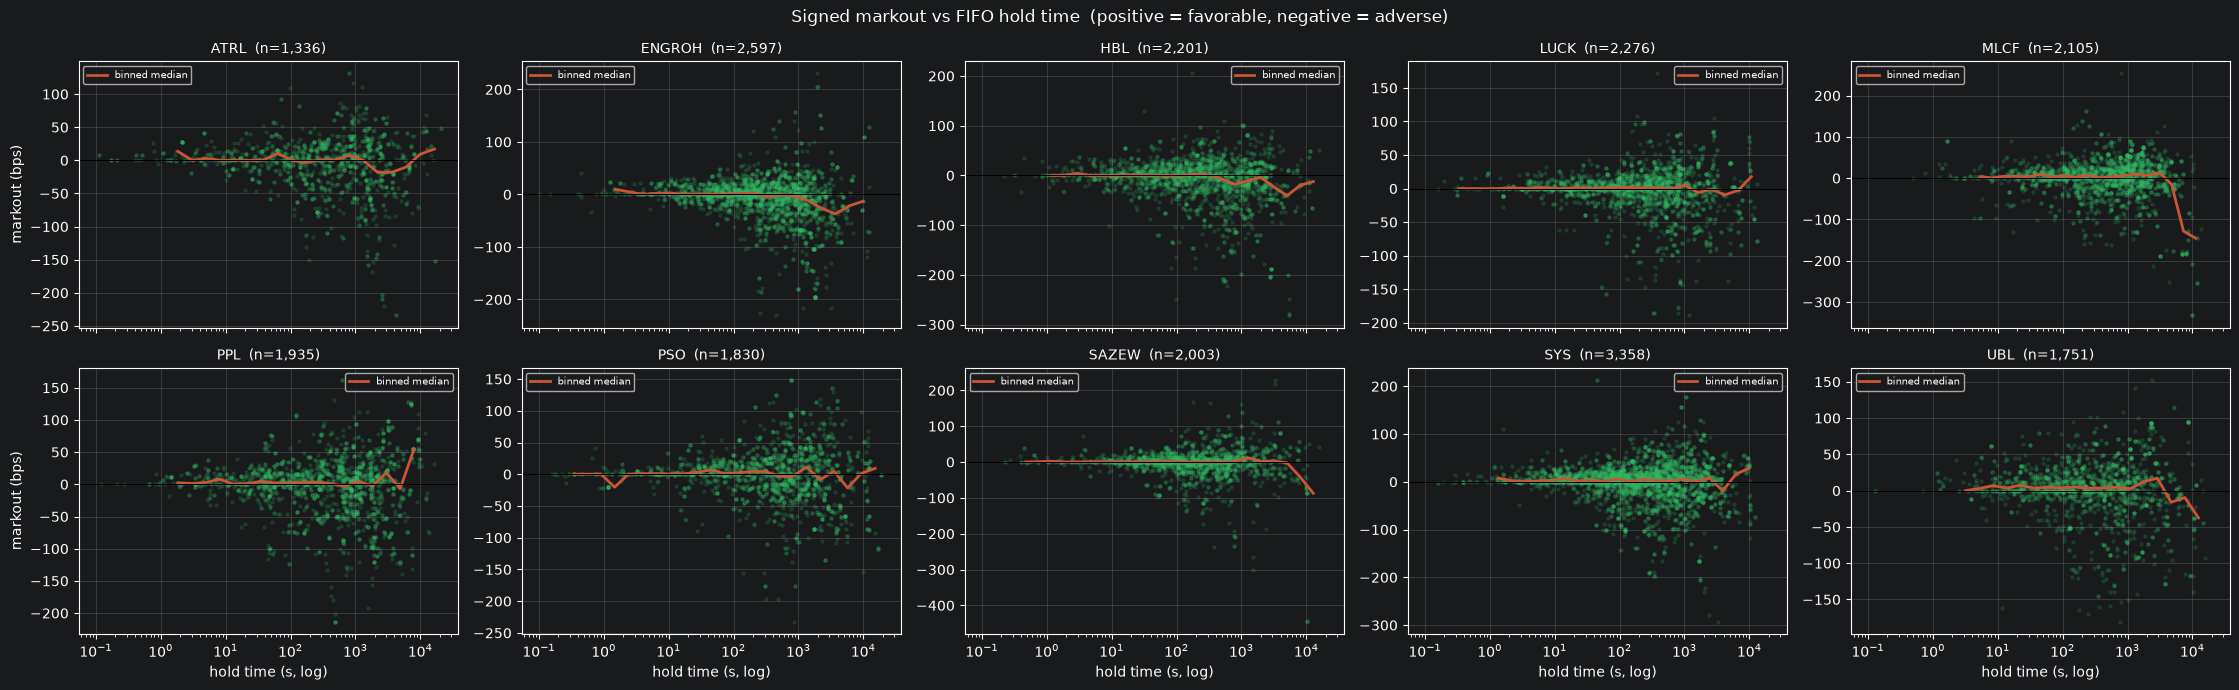

In [4]:
# a 5-col grid over the 10 tickers, log x (hold times span ms to hours)
tickers = sorted(mko.ticker.unique())
ncols = 5
nrows = int(np.ceil(len(tickers) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows),
                         squeeze=False, sharex=True)

# thin the scatter for legibility (very heavy scatter obscures the shape)
def thin(df, cap=8000):
    if len(df) <= cap: return df
    return df.sample(cap, random_state=0)

for i, tk in enumerate(tickers):
    ax = axes[i // ncols][i % ncols]
    d = mko[mko.ticker == tk]
    if len(d) == 0:
        ax.set_title(f"{tk} (no data)"); continue
    # keep sensible hold times (>= 100 ms so the log axis is clean)
    d = d[d.hold_s >= 0.1]
    # scatter
    ds = thin(d)
    ax.scatter(ds["hold_s"], ds["markout_bps"], s=5, alpha=0.15, color="#3b6")
    # binned median across log-spaced hold buckets
    if len(d) > 100:
        edges = np.logspace(np.log10(max(d.hold_s.min(), 0.1)),
                            np.log10(d.hold_s.max()), 25)
        idx = np.digitize(d.hold_s, edges)
        # per-bin median markout + bin centers
        med_x, med_y = [], []
        for k in range(1, len(edges)):
            mk = d.markout_bps[idx == k]
            if len(mk) >= 10:
                med_x.append(0.5 * (edges[k-1] + edges[k]))
                med_y.append(mk.median())
        if med_x:
            ax.plot(med_x, med_y, "-", color="#c53", lw=2, label="binned median")
    # zero line + labels
    ax.axhline(0, color="k", lw=0.7)
    ax.set_xscale("log")
    ax.set_title(f"{tk}  (n={len(d):,})", fontsize=10)
    ax.grid(alpha=0.3)
    if i // ncols == nrows - 1: ax.set_xlabel("hold time (s, log)")
    if i % ncols == 0: ax.set_ylabel("markout (bps)")
    ax.legend(fontsize=7)
# hide unused axes
for j in range(len(tickers), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
fig.suptitle("Signed markout vs FIFO hold time  (positive = favorable, negative = adverse)")
fig.tight_layout()
plt.show()


## 4. Scatter 2 — |markout| vs FIFO hold time, per ticker

Absolute magnitude drops the sign, so this shows **how big the moves are** as a
function of hold time — independent of direction.

**Reference lines:**
- **√t envelope** (dashed): what pure diffusion would predict (variance ∝ time,
  so |move| grows like √t). Fitted per ticker from the actual median absolute
  markout in the middle hold-time bucket, then extrapolated.
- Deviation *above* the √t line at long horizons = fat-tailed jump exposure.
- Deviation *above* at short horizons = adverse-selection concentration (fills
  getting picked immediately).

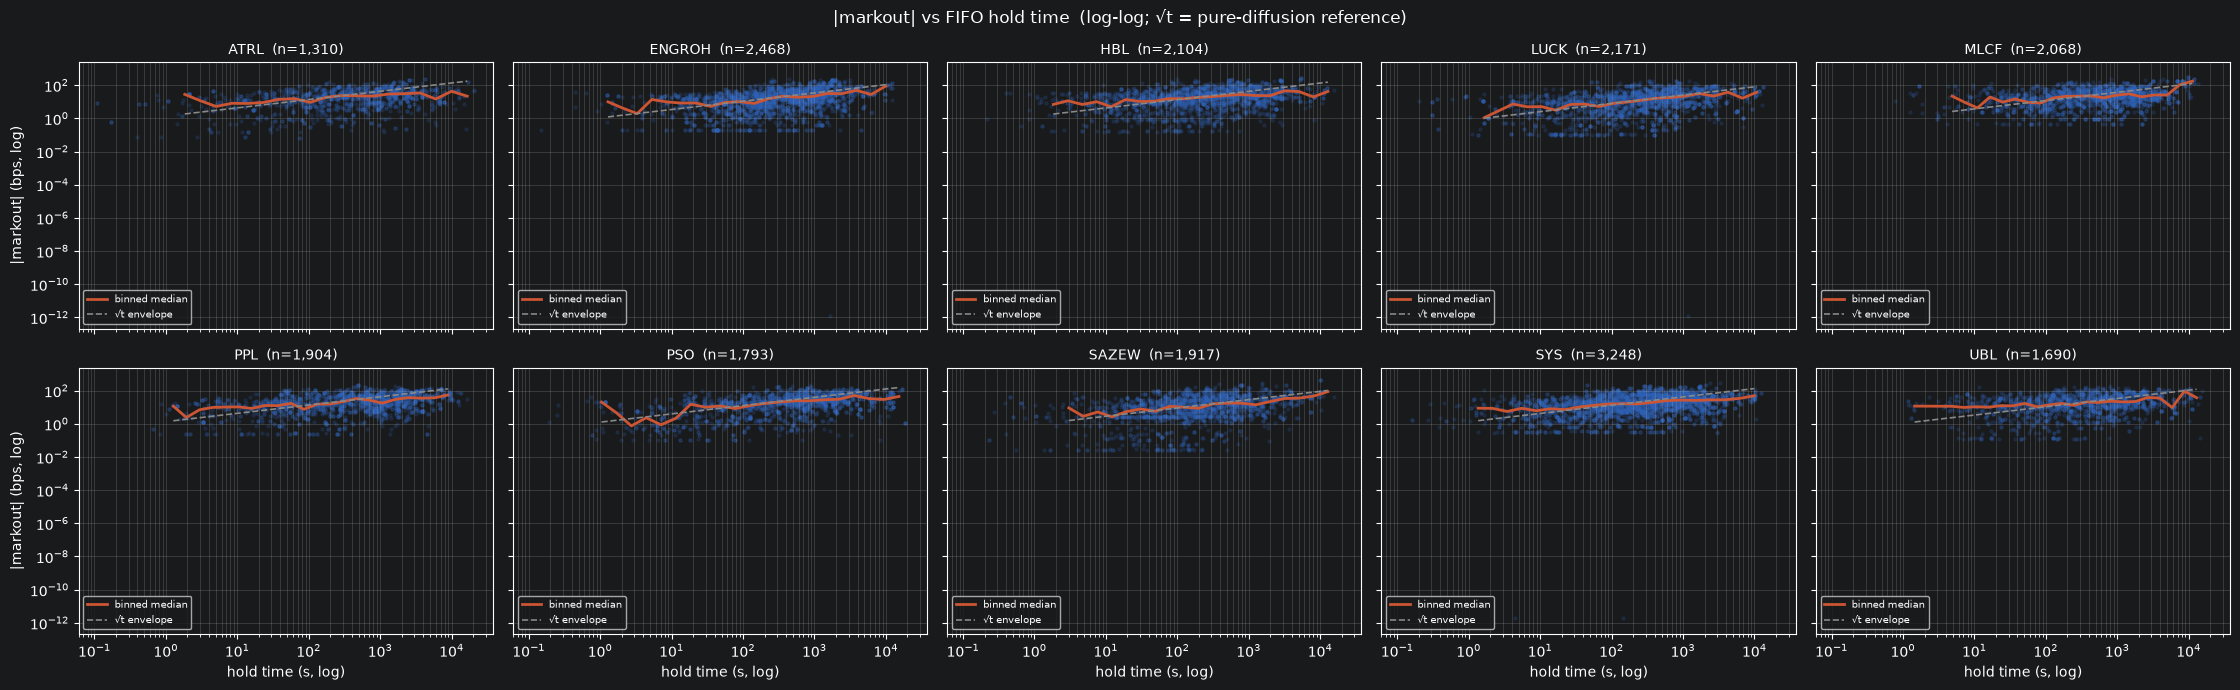

In [5]:
# same grid, absolute markout, log-log so both axes span the wide dynamic range
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows),
                         squeeze=False, sharex=True, sharey=True)
for i, tk in enumerate(tickers):
    ax = axes[i // ncols][i % ncols]
    d = mko[mko.ticker == tk]
    if len(d) == 0: ax.set_title(f"{tk} (no data)"); continue
    d = d[(d.hold_s >= 0.1) & (d.abs_markout_bps > 0)]
    if len(d) == 0:
        ax.set_title(f"{tk} (no positive |markout|)"); continue
    ds = thin(d)
    # scatter of |markout| vs hold time
    ax.scatter(ds["hold_s"], ds["abs_markout_bps"], s=5, alpha=0.15, color="#36b")
    # binned median across log-spaced buckets
    edges = np.logspace(np.log10(d.hold_s.min()), np.log10(d.hold_s.max()), 25)
    idx = np.digitize(d.hold_s, edges)
    med_x, med_y = [], []
    for k in range(1, len(edges)):
        mk = d.abs_markout_bps[idx == k]
        if len(mk) >= 10:
            med_x.append(0.5 * (edges[k-1] + edges[k]))
            med_y.append(mk.median())
    if med_x:
        ax.plot(med_x, med_y, "-", color="#c53", lw=2, label="binned median")
        # sqrt(t) envelope, anchored to the median of the middle third of the median curve
        mid = len(med_y) // 2
        if 0 < mid < len(med_y) - 1:
            anchor = np.array(med_y[max(0, mid-2):mid+3]).mean()
            xa = med_x[mid]
            sqrt_line = anchor * np.sqrt(np.array(med_x) / xa)
            ax.plot(med_x, sqrt_line, "--", color="#888", lw=1.2, label="√t envelope")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(f"{tk}  (n={len(d):,})", fontsize=10)
    ax.grid(alpha=0.3, which="both")
    if i // ncols == nrows - 1: ax.set_xlabel("hold time (s, log)")
    if i % ncols == 0: ax.set_ylabel("|markout| (bps, log)")
    ax.legend(fontsize=7)
for j in range(len(tickers), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
fig.suptitle("|markout| vs FIFO hold time  (log-log; √t = pure-diffusion reference)")
fig.tight_layout()
plt.show()


## 5. Reading the charts

**Signed markout (chart 1) — what to look for:**
- **Median curve near zero → market-making is fair on average** (capture is what you keep).
- **Median curve *below* zero → adverse selection dominates** (fills systematically picked).
- **Curve trending toward zero with longer holds** → short-hold toxicity that mean-reverts.
- **Asymmetric point cloud (heavier below)** → fat left tail, jump-driven adverse fills.

**|markout| (chart 2) — what to look for:**
- **Median tracks √t envelope closely** → toxicity is diffusive (well-behaved).
- **Median *above* √t at short holds** → adverse-selection concentration (informed pick-off).
- **Median *above* √t at long holds** → jump risk (or residual/EOD lots dominating the tail).
- **Median *below* √t** → mean-reversion in the mid path (unusual for a maker to see).

**On the capture question you asked:** capture is measured against the **mid**,
not the opposite touch. `capture = signed(mid_at_fill − our_px) × qty`. That's
the *half-spread* you earned by being passive at the fill instant. Using
opposite-touch instead would give the *full quoted spread* — the total round-trip
cost if a taker had crossed both sides — which overstates what a maker actually
earned on that fill by ~one half-spread.